In [1]:
import scipy
import sys
from skimage import io
import numpy as np
import numpy.matlib
import matplotlib
import skimage
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd
from numpy import matlib
import seaborn as sns
import math
import os
import scipy.optimize
import scipy.io as sio
from scipy import stats
import scipy.ndimage
from scipy.interpolate import make_smoothing_spline
from pathlib import Path

sns.set(font_scale=1.5)
sns.set_style("whitegrid")

In [2]:
# Experiment specifics
base_path="/Volumes/data_ssd3/Barber_Lab/data"
expt_id="/20260602_TEM_HPF"
conds=["/WT_sorb_A3802", "/ponA_mg_A3805", "/ponA_sorb_A3809", "/tago_mg_A3812", "/tago_sorb_A3815", "/WT_mg_A3799"]
threshs=(255.0-np.array([39,33,30,25,61,32]))/255.0
bkgds=(255.0-np.array([203.4,176.125,170,170,147,190]))/255.0


# Parameters
scale=500.0/762.0 # nm/pixel.
depth=200
opp_depth=int(10/scale) # distance in nm to backtrack — allows you to precisely measure the position of the membrane
window=9
min_depth=100 # minimum depth for us to consider a cross-section for analysis
cutoff_length=int(opp_depth+min_depth/scale)
cutoff=0.2 # Peak prominence cutoff for "membrane" detection
offset_ind=int(30/scale)
# num_fits=40
rel_val=0.7
spacing=4.0 # spacing in pixels between adjacent fits

col=['Condition', 'Cell number', 'Thickness (nm)']
cell_thickness_df=pd.DataFrame(columns=col)

contours=[]

for cond_ind in range(len(conds)):
    # Navigate to a specific condition
    contours.append([])
    cond=conds[cond_ind]
    bkgd=bkgds[cond_ind]
    peak_val=threshs[cond_ind]
    dirs = [item.name for item in Path(base_path+expt_id+'/trace'+cond).iterdir() if item.is_dir() and item.name!='plots']
    # Work through all images from that condition
    cell_count=0
    for temp_dir in dirs:
        print(temp_dir)
        im1=io.imread(base_path+expt_id+cond+'/'+temp_dir+'.tif')
        im2=im1[:,:,0]
        # Plotting data
        sns.set_style('white')
        fig=plt.figure(figsize=[10,10])
        plt.imshow(im1)
        # Work through all traces from that image
        cell_traces_list= [item.name for item in Path(base_path+expt_id+'/trace'+cond+'/'+temp_dir).glob(temp_dir+'*.csv')]
        for name in cell_traces_list:
            print(name)
            coords=pd.read_csv(base_path+expt_id+'/trace'+cond+'/'+temp_dir+'/'+name)
            xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
            lam=10
            if len(xv)<5: # We need to have additional points to make a spline of this sort
                xv1,yv1=np.copy(xv),np.copy(yv)
                while len(xv1)<5:
                    xv1,yv1=xv1[np.argsort(xv1)],yv1[np.argsort(xv1)]
                    temp_x,temp_y=np.mean(xv1[:2]),np.mean(yv1[:2])
                    xv1,yv1=np.append(xv1,temp_x),np.append(yv1,temp_y)
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv1[np.argsort(xv1)], yv1[np.argsort(xv1)], lam=lam)
            else:
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
            xnew = np.arange(np.amin(xv), np.amax(xv), spacing)[1:-1]
            xnew1 = np.arange(np.amin(xv), np.amax(xv), spacing/10.0)
            ynew1=spl(xnew1)
            intensity_vals=np.nan*np.ones([len(xnew),int(depth/scale)+opp_depth])
            # Plotting spline values
            plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
            # Calculate intensity along transverse slices
            slopes=[]
            for ind in np.arange(len(xnew)):
                point=np.nonzero(xnew1>xnew[ind])[0][0]
                slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
                slopes.append(slope)
                num_points=int(np.absolute(slope[0]*depth/scale)) # number of x values to change in order to get that amount of y change
                xs=np.sign(xv[-1]-xv[0])*np.sign(slope[0]) # determines whether x should increase or decrease.
                xrange=np.arange(xnew[ind],xnew[ind]-num_points,-1)
                yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
                # now let's unit-spaced coordinates along this line, from start to end.
                dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slope[0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slope[0]))
                xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                sel_vals=np.nonzero((xcoords>=0)*(xcoords<=im1.shape[1])*(ycoords>=0)*(ycoords<=im1.shape[0]))
                if len(sel_vals[0])>cutoff_length:
                    intensity_vals[ind,sel_vals]=(255.0-im2[ycoords[sel_vals].astype(int),xcoords[sel_vals].astype(int)])/255.0
    
            # Let's just take the average over the first 30nm and find the first point where this intensity drops by 1/2 the difference 
            # between the peak 
            final_inds=[]
            for temp_int in range(intensity_vals.shape[0]):
                if np.sum(np.isnan(intensity_vals[temp_int,:]))<intensity_vals.shape[1]:
                    signal=intensity_vals[temp_int,offset_ind:]

                    
                    # peak_val=np.nanmean(intensity_vals[temp_int,:offset_ind])
                    if np.sum(signal<(peak_val-0.5*(peak_val-bkgd)))>0:
                        final_inds.append(np.nonzero(signal<(peak_val-0.5*(peak_val-bkgd)))[0][0]+offset_ind)
                    else:
                        final_inds.append(np.nan)
                else:
                    final_inds.append(np.nan)

            contours[-1].append([np.nanmean(intensity_vals,axis=0)]) # after the fact we will go back and take the relevant averages
                    
            for ind in np.arange(len(xnew)):
                if ~np.isnan(final_inds[ind]):
                    xs=np.sign(xv[-1]-xv[0])*np.sign(slopes[ind][0]) # determines whether x should increase or decrease.
                    yrange=float(spl(xnew1[point]))-1.0/slopes[ind][0]*(xrange-xnew1[point])
                    # now let's unit-spaced coordinates along this line, from start to end.
                    dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slopes[ind][0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slopes[ind][0]))
                    xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                    temp_xcoords=[xcoords[opp_depth],xcoords[final_inds[ind]]]
                    temp_ycoords=[ycoords[opp_depth],ycoords[final_inds[ind]]]
                    plt.plot(temp_xcoords,temp_ycoords,'-',color='g',alpha=0.6)
                    temp_df=pd.DataFrame(columns=col,data=[[cond[1:],cell_count,scale*(final_inds[ind]-opp_depth)]])
                    cell_thickness_df=pd.concat([cell_thickness_df,temp_df])
            cell_count+=1
        if not(os.path.isdir(base_path+expt_id+'/trace'+cond+'/plots')):
            os.mkdir(base_path+expt_id+'/trace'+cond+'/plots')
        fig.savefig(base_path+expt_id+'/trace'+cond+'/plots/'+temp_dir+'.png',bbox_inches='tight',dpi=150)
        plt.close()

WT_sorb_10kX_0008
WT_sorb_10kX_0008_cell_2.csv
WT_sorb_10kX_0008_cell_1.csv
WT_sorb_10kX_0006
WT_sorb_10kX_0006_cell_1.csv
WT_sorb_10kX_0006_cell_3.csv
WT_sorb_10kX_0001
WT_sorb_10kX_0001_cell_2.csv
WT_sorb_10kX_0007
WT_sorb_10kX_0007_cell_1.csv
WT_sorb_10kX_0009
WT_sorb_10kX_0009_cell_2.csv
WT_sorb_10kX_0009_cell_1.csv
WT_sorb_10kX_0014
WT_sorb_10kX_0014_cell_3.csv
WT_sorb_10kX_0014_cell_2.csv
WT_sorb_10kX_0014_cell_1.csv
WT_sorb_10kX_0013
WT_sorb_10kX_0013_cell_1.csv
WT_sorb_10kX_0025
WT_sorb_10kX_0025_cell_1.csv
WT_sorb_10kX_0025_cell_2.csv
WT_sorb_10kX_0025_cell_3.csv
WT_sorb_10kX_0022
WT_sorb_10kX_0023
WT_sorb_10kX_0023_cell_2.csv
WT_sorb_10kX_0023_cell_1.csv
WT_sorb_10kX_0024
WT_sorb_10kX_0024_cell_1.csv
WT_sorb_10kX_0012
WT_sorb_10kX_0012_cell_1.csv
WT_sorb_10kX_0012_cell_2.csv
WT_sorb_10kX_0015
WT_sorb_10kX_0015_cell_1.csv
WT_sorb_10kX_0005
WT_sorb_10kX_0005_cell_1.csv
WT_sorb_10kX_0003
WT_sorb_10kX_0003_cell_2.csv
WT_sorb_10kX_0003_cell_1.csv
WT_sorb_10kX_0017
WT_sorb_10kX_001

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_39075/3893030373.py:101: RuntimeWarning: Mean of empty slice
  contours[-1].append([np.nanmean(intensity_vals,axis=0)]) # after the fact we will go back and take the relevant averages


ponA_mg_10kX_0005
ponA_mg_10kX_0005_cell_1.csv
ponA_mg_10kX_0005_cell_2.csv
ponA_mg_10kX_0004
ponA_mg_10kX_0004_cell_1.csv
ponA_mg_10kX_0004_cell_3.csv
ponA_mg_10kX_0003
ponA_mg_10kX_0003_cell_1.csv
ponA_mg_10kX_0013
ponA_mg_10kX_0013_cell_1.csv
ponA_mg_10kX_0022
ponA_mg_10kX_0022_cell_1.csv
ponA_mg_10kX_0023
ponA_mg_10kX_0023_cell_2.csv
ponA_mg_10kX_0023_cell_1.csv
ponA_mg_10kX_0024
ponA_mg_10kX_0024_cell_1.csv
ponA_mg_10kX_0012
ponA_mg_10kX_0012_cell_1.csv
ponA_mg_10kX_0012_cell_3.csv
ponA_mg_10kX_0006
ponA_mg_10kX_0006_cell_1.csv
ponA_mg_10kX_0006_cell_2.csv
ponA_mg_10kX_0007
ponA_mg_10kX_0007_cell_1.csv
ponA_mg_10kX_0007_cell_2.csv
ponA_mg_10kX_0009
ponA_mg_10kX_0009_cell_1.csv
ponA_sorb_10kX_0016
ponA_sorb_10kX_0016_cell_5.csv
ponA_sorb_10kX_0016_cell_4.csv
ponA_sorb_10kX_0016_cell_3.csv
ponA_sorb_10kX_0016_cell_2.csv
ponA_sorb_10kX_0016_cell_1.csv
ponA_sorb_10kX_0011
ponA_sorb_10kX_0018
ponA_sorb_10kX_0018_cell_1.csv
ponA_sorb_10kX_0020
ponA_sorb_10kX_0020_cell_2.csv
ponA_sorb_10

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_39075/3893030373.py:101: RuntimeWarning: Mean of empty slice
  contours[-1].append([np.nanmean(intensity_vals,axis=0)]) # after the fact we will go back and take the relevant averages


tago_sorb_10kX_0007
tago_sorb_10kX_0007_cell_1.csv
tago_sorb_10kX_0007_cell_2.csv
tago_sorb_10kX_0009
WT_mg_10kX_0028
WT_mg_10kX_0028_cell_2.csv
WT_mg_10kX_0028_cell_1.csv
WT_mg_10kX_0017
WT_mg_10kX_0017_cell_2.csv
WT_mg_10kX_0017_cell_1.csv
WT_mg_10kX_0010
WT_mg_10kX_0010_cell_1.csv
WT_mg_10kX_0019
WT_mg_10kX_0019_cell_4.csv
WT_mg_10kX_0019_cell_1.csv
WT_mg_10kX_0019_cell_3.csv
WT_mg_10kX_0019_cell_2.csv
WT_mg_10kX_0026
WT_mg_10kX_0026_cell_1.csv
WT_mg_10kX_0026_cell_2.csv
WT_mg_10kX_0018
WT_mg_10kX_0018_cell_1.csv
WT_mg_10kX_0027
WT_mg_10kX_0027_cell_1.csv
WT_mg_10kX_0027_cell_2.csv
WT_mg_10kX_0011
WT_mg_10kX_0011_cell_1.csv
WT_mg_10kX_0016
WT_mg_10kX_0016_cell_1.csv
WT_mg_10kX_0005
WT_mg_10kX_0005_cell_1.csv
WT_mg_10kX_0002
WT_mg_10kX_0002_cell_1.csv
WT_mg_10kX_0014
WT_mg_10kX_0014_cell_1.csv
WT_mg_10kX_0025
WT_mg_10kX_0025_cell_1.csv
WT_mg_10kX_0025_cell_2.csv
WT_mg_10kX_0024
WT_mg_10kX_0024_cell_1.csv


/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_39075/3893030373.py:101: RuntimeWarning: Mean of empty slice
  contours[-1].append([np.nanmean(intensity_vals,axis=0)]) # after the fact we will go back and take the relevant averages


WT_mg_10kX_0024_cell_2.csv
WT_mg_10kX_0024_cell_3.csv
WT_mg_10kX_0024_cell_4.csv
WT_mg_10kX_0023
WT_mg_10kX_0023_cell_4.csv
WT_mg_10kX_0023_cell_3.csv
WT_mg_10kX_0023_cell_2.csv
WT_mg_10kX_0023_cell_1.csv
WT_mg_10kX_0015
WT_mg_10kX_0015_cell_1.csv
WT_mg_10kX_0012
WT_mg_10kX_0012_cell_1.csv
WT_mg_10kX_0008
WT_mg_10kX_0008_cell_1.csv
WT_mg_10kX_0001
WT_mg_10kX_0001_cell_1.csv
WT_mg_10kX_0007
WT_mg_10kX_0007_cell_1.csv
WT_mg_10kX_0009


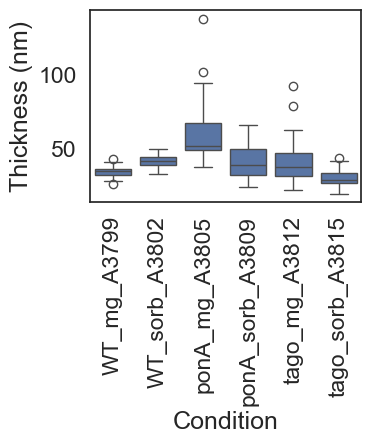

In [18]:
fig=plt.figure(figsize=[3.5,2.5])
sns.set_style('white')
temp_df_out=cell_thickness_df.groupby(['Condition','Cell number'])['Thickness (nm)'].median().reset_index()
# plot = sns.barplot(x='Condition', y='Thickness (nm)', data=temp_df_out, edgecolor='black', linewidth=1, native_scale=True, alpha=0.3, legend=False,capsize=0.2)
plot = sns.boxplot(x='Condition', y='Thickness (nm)', data=temp_df_out)
plt.xticks(rotation=90)
fig.savefig(base_path+expt_id+'/thickness_dist.png',dpi=300,bbox_inches='tight')

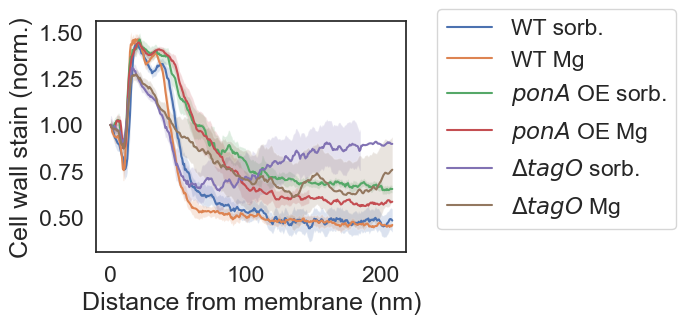

In [14]:
int_conts_ls=[]
fig=plt.figure(figsize=[4,3])
x=scale*np.arange(0,int(depth/scale)+opp_depth,1)
cutoff_num=2
cond_plotting=["/WT_sorb_A3802", "/WT_mg_A3799", "/ponA_sorb_A3809", "/ponA_mg_A3805", "/tago_sorb_A3815", "/tago_mg_A3812"]
cond_labels =["WT sorb.", "WT Mg", r"$ponA$ OE sorb.", r"$ponA$ OE Mg", r"$\Delta tagO$ sorb.", r"$\Delta tagO$ Mg"]
for cond in cond_plotting:
    ind=conds.index(cond)
    int_conts=np.nan*np.ones([len(contours[ind]),int(depth/scale)+opp_depth])
    for ind1 in range(len(contours[ind])):
        int_conts[ind1,:]=np.asarray(contours[ind][ind1])
    temp_v1=(np.sum(~np.isnan(int_conts),axis=0)<cutoff_num)
    for ind2 in range(int_conts.shape[1]):
        if temp_v1[ind2]:
            int_conts[:,ind2]=np.nan
    
        # if np.sum(~np.isnan(int_conts[:,ind2])<cutoff_num):
        #     int_conts[:,ind2]=np.nan*np.ones(int_conts.shape[0])
    int_conts_ls.append(int_conts)

    med=np.nanmedian(int_conts_ls[-1],axis=0)
    sel_vals=np.nonzero(~np.isnan(med))
    iqr=scipy.stats.iqr(int_conts_ls[-1],axis=0)
    med*=1.0/med[0]
    iqr*=1.0/med[0]
    med=med[sel_vals]
    iqr=iqr[sel_vals]
    plt.plot(x[sel_vals],med,label=cond_labels[cond_plotting.index(cond)])
    plt.fill_between(x[sel_vals],med+iqr/2.0,med-iqr/2.0,alpha=0.2)
plt.legend(loc=[1.1,0.1])
plt.xlabel('Distance from membrane (nm)')
plt.ylabel('Cell wall stain (norm.)')
fig.savefig(base_path+expt_id+'/wall_profile_norm.png',dpi=300,bbox_inches='tight')
plt.show()


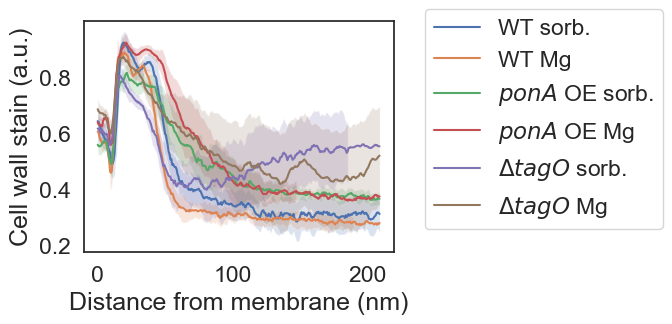

In [5]:
int_conts_ls=[]
fig=plt.figure(figsize=[4,3])
x=scale*np.arange(0,int(depth/scale)+opp_depth,1)
cutoff_num=2
cond_plotting=["/WT_sorb_A3802", "/WT_mg_A3799", "/ponA_sorb_A3809", "/ponA_mg_A3805", "/tago_sorb_A3815", "/tago_mg_A3812"]
cond_labels =["WT sorb.", "WT Mg", r"$ponA$ OE sorb.", r"$ponA$ OE Mg", r"$\Delta tagO$ sorb.", r"$\Delta tagO$ Mg"]
for cond in cond_plotting:
    ind=conds.index(cond)
    int_conts=np.nan*np.ones([len(contours[ind]),int(depth/scale)+opp_depth])
    for ind1 in range(len(contours[ind])):
        int_conts[ind1,:]=np.asarray(contours[ind][ind1])
    temp_v1=(np.sum(~np.isnan(int_conts),axis=0)<cutoff_num)
    for ind2 in range(int_conts.shape[1]):
        if temp_v1[ind2]:
            int_conts[:,ind2]=np.nan
    
        # if np.sum(~np.isnan(int_conts[:,ind2])<cutoff_num):
        #     int_conts[:,ind2]=np.nan*np.ones(int_conts.shape[0])
    int_conts_ls.append(int_conts)

    med=np.nanmedian(int_conts_ls[-1],axis=0)
    sel_vals=np.nonzero(~np.isnan(med))
    iqr=scipy.stats.iqr(int_conts_ls[-1],axis=0)
    # med*=1.0/med[0]
    # iqr*=1.0/med[0]
    med=med[sel_vals]
    iqr=iqr[sel_vals]
    plt.plot(x[sel_vals],med,label=cond_labels[cond_plotting.index(cond)])
    plt.fill_between(x[sel_vals],med+iqr/2.0,med-iqr/2.0,alpha=0.2)
plt.legend(loc=[1.1,0.1])
plt.xlabel('Distance from membrane (nm)')
plt.ylabel('Cell wall stain (a.u.)')
fig.savefig(base_path+expt_id+'/wall_profile.png',dpi=300,bbox_inches='tight')
plt.show()
